In [1]:

import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
df = pd.read_csv('acr_ac_scenarios.csv')
df.head()

,panel,scenario-id,scenario-text,scenario-url,sex,age,body-area,priority-clinical-areas
0,Breast,3110141,"Axillary adenopathy, breast cancer suspected",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=3209,Male Only,18 - 150,Breast,NaN
1,Breast,3194817,"Axillary lump, palpable, new, bilateral, initial axilla imaging",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=5930,Female Only,18 - 150,Breast,NaN
2,Breast,3194815,"Axillary lump, palpable, new, unilateral, initial axilla imaging",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=5929,Female Only,18 - 150,Breast,NaN
3,Breast,3194837,"Axillary node, suspicious on imaging, not mammo or US, next imaging study",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=5940,Female Only,18 - 150,Breast,NaN
4,Breast,3194835,"Axillary node, suspicious on mammo or US, next imaging study",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=5939,Female Only,18 - 150,Breast,NaN


In [2]:
len(df)

3346

In [3]:
df['age'].unique()

<StringArray>
[   '18 - 150',    '25 - 150',    '30 - 150',    '40 - 150',     '12 - 29',
     '30 - 39',     '10 - 60',     '40 - 60',     '18 - 29',      '0 - 24',
      '0 - 29',      '0 - 17',     '0 - 150',    '45 - 150',    '12 - 150',
     '5 - 150',    '16 - 150',     '18 - 49',     '6 - 150',    '10 - 150',
       '0 - 9',    '65 - 150',     '16 - 64',    '50 - 150',    '70 - 150',
    '80 - 150',    '51 - 150',       '0 - 7',       '0 - 8',    '66 - 150',
      '0 - 15',  'D90 - 6205',    'D0 - 729',       '45339',       '0 - 1',
    'D0 - 119', 'D181 - 6205',  'D120 - 180',     'D0 - 27',   'D28 - 119',
    'D0 - 179',     'D0 - 29',       '45366',       '0 - 3',       '0 - 4',
       '45429', 'D180 - 6205',       '0 - 5',     'D0 - 30',  'D31 - 6205',
       '45582',  'D30 - 1095',       '45368',       '0 - 2', 'D180 - 1825',
  'D30 - 6205',     'D0 - 28',     'D0 - 59',  'D60 - 2190',       '45490',
      'D0 - 2',    'D3 - 365',    'D15 - 90',     '50 - 80',    '35 - 150'

In [4]:
df['body-area'].unique()

<StringArray>
[              'Breast',        'Cardiac-chest', 'Chest-abdomen-pelvis',
        'Chest-abdomen',              'Cardiac',                'Chest',
 'cardiac-chest-pelvis',       'Abdomen-pelvis',              'Abdomen',
               'Pelvis',           'Neck-chest',          'Unspecified',
          'Extremities',                'Spine',      'Lower extremity',
      'Upper extremity',         'Spine-pelvis',                 'Head',
                 'Neck',            'Head-neck',              'Maxface',
           'Head-spine']
Length: 22, dtype: str

In [5]:

filtered_df = df[df['body-area'].isin(['Chest-abdomen', 'Chest-abdomen-pelvis', 'Abdomen-pelvis', 'Abdomen', 'Pelvis'])]
body_area_n = len(filtered_df)
print(body_area_n)

620


In [6]:
filtered_df = filtered_df[filtered_df['panel'] != 'Pediatric']
without_peds_n = len(filtered_df)
print(without_peds_n)

562


In [7]:

filtered_df = filtered_df[~filtered_df['scenario-text'].str.contains('pregnant', case=False, na=False)]
without_pregnant_n = len(filtered_df)
print(without_pregnant_n)

547


In [8]:
filtered_df = filtered_df[filtered_df['panel'] != 'Interventional Radiology']
without_IR_n = len(filtered_df)
print(without_IR_n)

509


In [9]:
pattern_list = ['staging', 
                'screen', 
                'surveillance',
                'incidental finding',
                'imaging during treatment',
                'posttreatment imaging',
                'post treatment imaging',
                'preop planning',
                'pre-op planning'
                ]

pattern = '|'.join(pattern_list)
filtered_df = filtered_df[~filtered_df['scenario-text'].str.contains(pattern, case=False, na=False)]
without_monitoring_n = len(filtered_df)
print(without_monitoring_n)

398


In [10]:
# removed_pelvis_df = filtered_df[filtered_df['body-area'] == 'Pelvis']
# filtered_df = filtered_df[filtered_df['body-area'] != 'Pelvis']
# without_pelvis_n = len(filtered_df)
# print(without_pelvis_n)

In [11]:
specific_scenarios_to_include = pd.read_csv('include.csv')
specific_scenarios_to_exclude = pd.read_csv('exclude.csv')

filtered_df = pd.concat([filtered_df, df[df['scenario-id'].isin(specific_scenarios_to_include['scenario-id'])]])
filtered_df = filtered_df[~filtered_df['scenario-id'].isin(specific_scenarios_to_exclude['scenario-id'])]


In [12]:

# Find duplicate scenario texts
duplicate_scenarios = filtered_df[filtered_df.duplicated(subset=['scenario-text'], keep=False)]
duplicate_scenarios = duplicate_scenarios.sort_values('scenario-text')
print(f"Found {len(duplicate_scenarios)} rows with duplicate scenarios")
display(duplicate_scenarios)


Found 102 rows with duplicate scenarios


,panel,scenario-id,scenario-text,scenario-url,sex,age,body-area,priority-clinical-areas
183,Cardiac,3195891,"Arterial occlusion, lower extremity, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6712,All,18 - 150,Chest-abdomen-pelvis,NaN
3200,Vascular,3195891,"Arterial occlusion, lower extremity, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6712,All,18 - 150,Chest-abdomen-pelvis,NaN
184,Cardiac,3195887,"Arterial occlusion, mesenteric arterial system, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6709,All,18 - 150,Chest-abdomen,NaN
3201,Vascular,3195887,"Arterial occlusion, mesenteric arterial system, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6709,All,18 - 150,Chest-abdomen,NaN
185,Cardiac,3195888,"Arterial occlusion, renal arterial system, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6710,All,18 - 150,Chest-abdomen,NaN
3202,Vascular,3195888,"Arterial occlusion, renal arterial system, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6710,All,18 - 150,Chest-abdomen,NaN
186,Cardiac,3195889,"Arterial occlusion, renal infarcts, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6711,All,18 - 150,Chest-abdomen,NaN
3203,Vascular,3195889,"Arterial occlusion, renal infarcts, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6711,All,18 - 150,Chest-abdomen,NaN
187,Cardiac,3195885,"Arterial occlusion, upper extremity, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6708,All,18 - 150,Chest-abdomen,NaN
3204,Vascular,3195885,"Arterial occlusion, upper extremity, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6708,All,18 - 150,Chest-abdomen,NaN


In [13]:
studies = pd.read_csv('data/combined.csv')
studies.head()

,Unnamed: 0,panel,scenario-text,scenario-id,procedure,adult-rrl,peds-rrl,appropriateness
0,0,Pediatric,"Acquired coronary artery abnormality suspected, TTE inadequate assessment of coronary morphology, next imaging study",3196446,MRA chest without and with IV contrast,0 mSvO,0 mSv [ped]O,Usually appropriate
1,0,Pediatric,"Acquired coronary artery abnormality suspected, TTE inadequate assessment of coronary morphology, next imaging study",3196446,MRA chest without and with IV contrast,0 mSvO,0 mSv [ped]O,Usually appropriate
2,1,Pediatric,"Acquired coronary artery abnormality suspected, TTE inadequate assessment of coronary morphology, next imaging study",3196446,MRA chest without IV contrast,0 mSvO,0 mSv [ped]O,Usually appropriate
3,2,Pediatric,"Acquired coronary artery abnormality suspected, TTE inadequate assessment of coronary morphology, next imaging study",3196446,MRI heart function and morphology without and with IV contrast,0 mSvO,0 mSv [ped]O,Usually appropriate
4,3,Pediatric,"Acquired coronary artery abnormality suspected, TTE inadequate assessment of coronary morphology, next imaging study",3196446,MRI heart function and morphology without IV contrast,0 mSvO,0 mSv [ped]O,Usually appropriate


In [14]:
studies['procedure'].unique()

<StringArray>
[                             'MRA chest without and with IV contrast',
                                       'MRA chest without IV contrast',
      'MRI heart function and morphology without and with IV contrast',
               'MRI heart function and morphology without IV contrast',
                              'CTA coronary arteries with IV contrast',
                        'Arteriography coronary with ventriculography',
                            'MRA abdomen without and with IV contrast',
         'MRI heart function with stress without and with IV contrast',
                  'MRI heart function with stress without IV contrast',
                                          'CTA chest with IV contrast',
 ...
                                     'US pregnant uterus transvaginal',
                                              'US assessment for TTTS',
                                   'US duplex Doppler pregnant uterus',
                                            '

In [15]:
studies['appropriateness'].unique()

<StringArray>
[              'Usually appropriate',                'May be appropriate',
 'May be appropriate (Disagreement)',           'Usually not appropriate']
Length: 4, dtype: str

In [16]:
for scenario_text in duplicate_scenarios['scenario-text'].unique():
    scenario_rows = duplicate_scenarios[duplicate_scenarios['scenario-text'] == scenario_text]
    for index, row in scenario_rows.iterrows():
        scenario_id = row['scenario-id']
        studies_for_scenario = studies[studies['scenario-id'] == scenario_id]['procedure'].tolist()
        studies_for_scenario = set(studies_for_scenario)
        
        if index == scenario_rows.index[0]:
            first_studies_set = studies_for_scenario
            has_different_studies = False
        else:
            if studies_for_scenario != first_studies_set:
                has_different_studies = True
                print("Discrepancy found for scenario-id:", scenario_id)



In [17]:

filtered_df = filtered_df.drop_duplicates(subset=['scenario-text'], keep='first')
without_duplicates_n = len(filtered_df)
without_duplicates_n

227

In [18]:

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Funnel(
    name = 'ACR Criteria',
    y = ['All Scenarios', 'Limit by Body Area', 'Without Pediatrics', 'Without Pregnant', 'Without IR', 'Without Monitoring<br>("Staging", "Screen", "Surveillance")', 'Without Duplicate Scenarios'],
    x = [len(df), body_area_n, without_peds_n, without_pregnant_n, without_IR_n, without_monitoring_n, without_duplicates_n],
    textinfo = "value+percent initial"
))

fig.update_layout(
    title = "ACR Criteria Funnel Analysis",
    showlegend = True,
    width = 800,
    height = 500
)

fig.show()


In [19]:
removed_df = df[~df.index.isin(filtered_df.index)]
len(removed_df)

3119

In [20]:

# with pd.ExcelWriter('category_analysis.xlsx') as writer:
#     filtered_df.to_excel(writer, sheet_name='Filtered Rows', index=False)
#     removed_df.to_excel(writer, sheet_name='All Removed Rows', index=False)


In [21]:
filtered_df.head()

,panel,scenario-id,scenario-text,scenario-url,sex,age,body-area,priority-clinical-areas
183,Cardiac,3195891,"Arterial occlusion, lower extremity, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6712,All,18 - 150,Chest-abdomen-pelvis,NaN
184,Cardiac,3195887,"Arterial occlusion, mesenteric arterial system, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6709,All,18 - 150,Chest-abdomen,NaN
185,Cardiac,3195888,"Arterial occlusion, renal arterial system, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6710,All,18 - 150,Chest-abdomen,NaN
186,Cardiac,3195889,"Arterial occlusion, renal infarcts, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6711,All,18 - 150,Chest-abdomen,NaN
187,Cardiac,3195885,"Arterial occlusion, upper extremity, embolic etiology suspected, next imaging study, determine source",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=6708,All,18 - 150,Chest-abdomen,NaN


Questions to answer, for each scenario, does the ACR recommend?
- No imaging (all studies are rated as “usually not appropriate”)
- CT is the ONLY “usually appropriate” imaging
- CT and other modalities are “usually appropriate” imaging (“alternatives to CT possible”)
- CT not “usually appropriate”
    - CT is “may be appropriate”
    - CT “usually not appropriate”

In [22]:

# Create empty dataframe to store all scenario studies
all_scenario_studies = pd.DataFrame()

for index, scenario in filtered_df.iterrows():
    # Get all studies for this scenario
    scenario_studies = studies[studies['scenario-id'] == scenario['scenario-id']]
    
    # # Add scenario ID and text to each row
    # scenario_studies.insert(0, 'scenario-text', scenario['scenario-text'])
    # scenario_studies.insert(0, 'scenario-id', scenario['scenario-id'])
    
    # Append to the combined dataframe
    all_scenario_studies = pd.concat([all_scenario_studies, scenario_studies], ignore_index=True)



# Write dataframe to Excel file
# all_scenario_studies.to_excel('scenario_studies.xlsx', index=False)



In [23]:

for index, scenario in filtered_df.iterrows():
    # Get all studies for this scenario
    scenario_studies = studies[studies['scenario-id'] == scenario['scenario-id']]
    
    # Check if any CT procedures are usually appropriate
    ct_studies = scenario_studies[
        (scenario_studies['procedure'].str.startswith('CT', na=False)) & 
        (scenario_studies['appropriateness'] == 'Usually appropriate')
    ]
    filtered_df.at[index, 'ct_usually_appropriate'] = len(ct_studies) > 0
    
    # Check if any CT procedures are may be appropriate
    ct_studies = scenario_studies[
        (scenario_studies['procedure'].str.startswith('CT', na=False)) & 
        (scenario_studies['appropriateness'] == 'May be appropriate')
    ]
    filtered_df.at[index, 'ct_may_be_appropriate'] = len(ct_studies) > 0

    # Check if any CT procedures are NOT appropriate
    ct_inappropriate_studies = scenario_studies[
        (scenario_studies['procedure'].str.startswith('CT', na=False)) & 
        (scenario_studies['appropriateness'] == 'Usually not appropriate')
    ]
    filtered_df.at[index, 'ct_not_appropriate'] = len(ct_inappropriate_studies) > 0
    
    # Are non CT studies usually appropriate?
    non_ct_studies = scenario_studies[
        (~scenario_studies['procedure'].str.startswith('CT', na=False)) & 
        (scenario_studies['appropriateness'] == 'Usually appropriate')
    ]
    filtered_df.at[index, 'other_usually_appropriate'] = len(non_ct_studies) > 0

    # Are non CT studies maybe appropriate?
    non_ct_studies = scenario_studies[
        (~scenario_studies['procedure'].str.startswith('CT', na=False)) & 
        (scenario_studies['appropriateness'] == 'May be appropriate')
    ]
    filtered_df.at[index, 'other_may_be_appropriate'] = len(non_ct_studies) > 0

    # Are non CT studies NOT appropriate?
    non_ct_studies = scenario_studies[
        (~scenario_studies['procedure'].str.startswith('CT', na=False)) & 
        (scenario_studies['appropriateness'] == 'Usually not appropriate')
    ]
    filtered_df.at[index, 'other_not_appropriate'] = len(non_ct_studies) > 0


In [24]:

filtered_df[['ct_usually_appropriate', 'other_usually_appropriate', 'ct_may_be_appropriate', 'other_may_be_appropriate', 'ct_not_appropriate', 'other_not_appropriate']].describe()


,ct_usually_appropriate,other_usually_appropriate,ct_may_be_appropriate,other_may_be_appropriate,ct_not_appropriate,other_not_appropriate
count,227,227,227,227,227,227
unique,2,2,2,2,2,2
top,True,True,True,True,True,True
freq,157,176,145,174,190,199


Some type of CT study appears in almost every scenario.

In [25]:
percentage_with_ct = filtered_df[['ct_usually_appropriate', 'ct_may_be_appropriate', 'ct_not_appropriate']].any(axis=1).mean() * 100
print(f"Percentage of scenarios where a CT study is listed as 'usually appropriate', 'may be appropriate', or 'not appropriate': {percentage_with_ct:.2f}%")

Percentage of scenarios where a CT study is listed as 'usually appropriate', 'may be appropriate', or 'not appropriate': 99.56%


There are a number of different CT studies addressed in the ACR criteria for the included scenarios.

In [26]:

studies[
    (studies['procedure'].str.startswith('CT', na=False)) & 
    (studies['scenario-id'].isin(filtered_df['scenario-id']))
]['procedure'].unique()

<StringArray>
[             'CTA abdomen and pelvis with IV contrast',
  'CTA abdomen and pelvis without and with IV contrast',
               'CT abdomen and pelvis with IV contrast',
            'CT abdomen and pelvis without IV contrast',
   'CT abdomen and pelvis without and with IV contrast',
               'CTA chest and abdomen with IV contrast',
                'CT chest and abdomen with IV contrast',
             'CT chest and abdomen without IV contrast',
    'CT chest and abdomen without and with IV contrast',
                           'CTA chest with IV contrast',
    'CT heart function and morphology with IV contrast',
            'CTA chest abdomen pelvis with IV contrast',
                         'CTA abdomen with IV contrast',
              'CTV abdomen and pelvis with IV contrast',
                 'CTV lower extremity with IV contrast',
             'CT chest abdomen pelvis with IV contrast',
 'CT chest abdomen pelvis without and with IV contrast',
          'CT che

There is a high degree of overlap between the categories of "usually appropriate", "may be appropriate", and "usually inappropriate". The classification depends largely on the type of CT study. e.g. When evaluating abdominal pain, a CT with IV contrast is usually appropriate, a CT without IV contrast may be appropriate, and a CT with and without IV contrast is usually inappropriate.

**Conclusion**: The type of CT ordered matters.

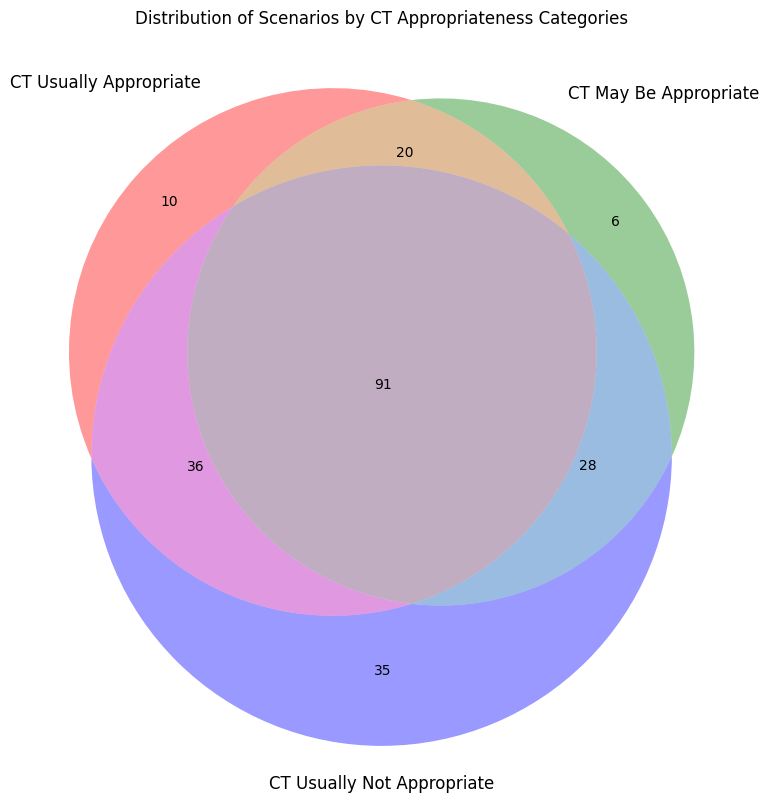

In [27]:

from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# Create sets for each category
usually_appropriate = set(filtered_df[filtered_df['ct_usually_appropriate'] == 1].index)
may_be_appropriate = set(filtered_df[filtered_df['ct_may_be_appropriate'] == 1].index)
not_appropriate = set(filtered_df[filtered_df['ct_not_appropriate'] == 1].index)

# Create Venn diagram
plt.figure(figsize=(10, 10))
venn3([usually_appropriate, may_be_appropriate, not_appropriate], 
      set_labels=('CT Usually Appropriate', 'CT May Be Appropriate', 'CT Usually Not Appropriate'))
plt.title('Distribution of Scenarios by CT Appropriateness Categories')
plt.show()


Some type of CT study is classified as "usually appropriate" in 68.1% of included scenarios

In [28]:
n_usually_appropriate = filtered_df['ct_usually_appropriate'].sum()
percentage_usually_appropriate = (n_usually_appropriate / len(filtered_df)) * 100
print(f"Number of scenarios where a CT study is usually appropriate: {n_usually_appropriate}")
print(f"Percentage of scenarios where a CT study is usually appropriate: {percentage_usually_appropriate:.2f}%")
display(filtered_df[filtered_df['ct_usually_appropriate']]['scenario-text'])

Number of scenarios where a CT study is usually appropriate: 157
Percentage of scenarios where a CT study is usually appropriate: 69.16%


183                                                              Arterial occlusion, lower extremity, embolic etiology suspected, next imaging study, determine source
184                                                   Arterial occlusion, mesenteric arterial system, embolic etiology suspected, next imaging study, determine source
185                                                        Arterial occlusion, renal arterial system, embolic etiology suspected, next imaging study, determine source
186                                                               Arterial occlusion, renal infarcts, embolic etiology suspected, next imaging study, determine source
187                                                              Arterial occlusion, upper extremity, embolic etiology suspected, next imaging study, determine source
188                                                          Arterial occlusions, multi organ system, embolic etiology suspected, next imaging study, determine sourc

In [29]:

filtered_df_ct_ua = filtered_df[filtered_df['ct_usually_appropriate'] == True]
n_other_appropriate = (filtered_df_ct_ua['other_usually_appropriate'] == True).sum()
percentage = (filtered_df_ct_ua['other_usually_appropriate'] == True).mean() * 100
print(f"Of records where CT is Usually Appropriate, {percentage:.1f}% (n={n_other_appropriate}) also have a non-CT study as usually appropriate")


Of records where CT is Usually Appropriate, 70.1% (n=110) also have a non-CT study as usually appropriate


In [30]:

percentage_neither = len(filtered_df[(filtered_df['ct_usually_appropriate'] == False) & (filtered_df['ct_may_be_appropriate'] == False)]) / len(filtered_df) * 100
print(f"Percentage of scenarios where a CT study is neither 'usually appropriate' nor 'may be appropriate': {percentage_neither:.2f}%")
# display(filtered_df[(filtered_df['ct_usually_appropriate'] == False) & (filtered_df['ct_may_be_appropriate'] == False)])

Percentage of scenarios where a CT study is neither 'usually appropriate' nor 'may be appropriate': 15.86%


In [31]:

# Calculate rows where ct_usually_appropriate is True and other_usually_appropriate is False
ct_only_appropriate = filtered_df[(filtered_df['ct_usually_appropriate'] == True) & (filtered_df['other_usually_appropriate'] == False)]
num_ct_only = len(ct_only_appropriate)
pct_ct_only = (num_ct_only / len(filtered_df)) * 100

print(f"Number of cases where only CT is usually appropriate: {num_ct_only}")
print(f"Percentage of cases where only CT is usually appropriate: {pct_ct_only:.1f}%")


Number of cases where only CT is usually appropriate: 47
Percentage of cases where only CT is usually appropriate: 20.7%


In [32]:
filtered_df[(filtered_df['ct_usually_appropriate'] == False) & (filtered_df['ct_may_be_appropriate'] == False)]['scenario-text']

295                                                                Epigastric pain, hiatal hernia suspected, initial imaging
450                                                                                 Endometriosis suspected, initial imaging
451                                                                   Endometriosis suspected, rectosigmoid, initial imaging
452                                          Endometriosis suspected, US indeterminate, next imaging study, characterization
453                                        Endometriosis suspected, US indeterminate, next imaging study, treatment planning
454                                               Endometriosis suspected, US negative, next imaging study, characterization
455                                             Endometriosis suspected, US negative, next imaging study, treatment planning
456                                                  Endometriosis, postoperative diagnosis, new symptoms, follow-up imaging


In [33]:

appropriate_percentage = (
    (filtered_df['ct_usually_appropriate'] | filtered_df['ct_may_be_appropriate']).mean() * 100
)
n_usually_or_may_be_appropriate = (
    (filtered_df['ct_usually_appropriate'] | filtered_df['ct_may_be_appropriate']).sum()
)
print(f"Percentage of cases where CT is usually or may be appropriate: {appropriate_percentage:.2f}% (n={n_usually_or_may_be_appropriate})")


Percentage of cases where CT is usually or may be appropriate: 84.14% (n=191)


**Conclusion:** For the included scenarios, choosing to order a CT study may be a reasonable option.

According to the ACR, the following scenarios, it is not "usually appropriate" to order a CT study, but "may be appropriate."

In [34]:
filtered_df[(filtered_df['ct_usually_appropriate'] == False) & (filtered_df['ct_may_be_appropriate'] == True)]['scenario-text']


258     Abnormal liver function tests, hepatocellular predominance, mild aminotransferase increase , initial imaging
290                                                          Epigastric pain, acid reflux suspected, initial imaging
291                                                       Epigastric pain, duodenal ulcer suspected, initial imaging
292                                                          Epigastric pain, esophagitis suspected, initial imaging
294                                                            Epigastric pain, gastritis suspected, initial imaging
296                                                         Epigastric pain, peptic ulcer suspected, initial imaging
316                                           Liver lesion, <1cm, indeterminate on US, hx of extrahepatic malignancy
340                                                                     Pancreatitis suspected, typical presentation
357                                   RUQ pain, acalculous chole

According to the ACR, in the following scenarios, it is "usually not appropriate" to order any CT study.

In [35]:
ct_not_appropriate_studies = filtered_df[(filtered_df['ct_usually_appropriate'] == False) & 
           (filtered_df['ct_may_be_appropriate'] == False) &
           (filtered_df['ct_not_appropriate'] == True)]['scenario-text']
print(len(ct_not_appropriate_studies))
print(len(ct_not_appropriate_studies) / len(filtered_df)*100)
ct_not_appropriate_studies


35
15.418502202643172


295                                                                Epigastric pain, hiatal hernia suspected, initial imaging
450                                                                                 Endometriosis suspected, initial imaging
451                                                                   Endometriosis suspected, rectosigmoid, initial imaging
452                                          Endometriosis suspected, US indeterminate, next imaging study, characterization
453                                        Endometriosis suspected, US indeterminate, next imaging study, treatment planning
454                                               Endometriosis suspected, US negative, next imaging study, characterization
455                                             Endometriosis suspected, US negative, next imaging study, treatment planning
456                                                  Endometriosis, postoperative diagnosis, new symptoms, follow-up imaging


In the following studies, the ACR defines no studies (CT or otherwise) as "usually appropriate" or "may be appropriate".

In [36]:

filtered_df[(filtered_df['ct_usually_appropriate'] == False) & 
           (filtered_df['ct_may_be_appropriate'] == False) & 
           (filtered_df['other_usually_appropriate'] == False) & 
           (filtered_df['other_may_be_appropriate'] == False)]['scenario-text']


3106    Pyelonephritis suspected, acute, uncomplicated, first time presentation, initial imaging
3184                         UTI, lower urinary tract, recurrent, uncomplicated, no risk factors
Name: scenario-text, dtype: str

In [37]:
#
# ======================== new category analysis begins here ============================
#

In [38]:
# green-green: True only if CT and alternative are usually appropriate

filtered_df['green-green'] = (filtered_df['ct_usually_appropriate'] == True) & \
                            (filtered_df['other_usually_appropriate'] == True)

print(f"Added 'green-green' column with {filtered_df['green-green'].sum()} True values out of {len(filtered_df)} rows")
filtered_df[filtered_df['green-green']][['scenario-text', 'ct_usually_appropriate', 'other_usually_appropriate', 'green-green']]


Added 'green-green' column with 110 True values out of 227 rows


,scenario-text,ct_usually_appropriate,other_usually_appropriate,green-green
183,"Arterial occlusion, lower extremity, embolic etiology suspected, next imaging study, determine source",True,True,True
184,"Arterial occlusion, mesenteric arterial system, embolic etiology suspected, next imaging study, determine source",True,True,True
185,"Arterial occlusion, renal arterial system, embolic etiology suspected, next imaging study, determine source",True,True,True
186,"Arterial occlusion, renal infarcts, embolic etiology suspected, next imaging study, determine source",True,True,True
187,"Arterial occlusion, upper extremity, embolic etiology suspected, next imaging study, determine source",True,True,True
188,"Arterial occlusions, multi organ system, embolic etiology suspected, next imaging study, determine source",True,True,True
248,"Abd pain, acute, nonlocalized, initial exam",True,True,True
250,"Abdominal mass, intra-abdominal neoplasm suspected",True,True,True
251,"Abdominal wall hernia suspected, incisional, initial imaging",True,True,True
252,"Abdominal wall hernia suspected, lumbar, initial imaging",True,True,True


In [39]:
# green-yellow: True if CT is usually appropriate but alternative is only maybe appropriate

filtered_df['green-yellow'] = (filtered_df['ct_usually_appropriate'] == True) & \
                             (filtered_df['other_usually_appropriate'] == False) & \
                             (filtered_df['other_may_be_appropriate'] == True)

print(f"Added 'green-yellow' column with {filtered_df['green-yellow'].sum()} True values out of {len(filtered_df)} rows")
filtered_df[filtered_df['green-yellow']][['scenario-text', 'ct_usually_appropriate', 'other_usually_appropriate', 'other_may_be_appropriate', 'green-yellow']]


Added 'green-yellow' column with 45 True values out of 227 rows


,scenario-text,ct_usually_appropriate,other_usually_appropriate,other_may_be_appropriate,green-yellow
246,"Abd pain, acute, nonlocalized, fever, initial exam",True,False,True,True
247,"Abd pain, acute, nonlocalized, fever, post op, initial exam",True,False,True,True
249,"Abd pain, acute, nonlocalized, neutropenic, initial exam",True,False,True,True
265,"Abscess, liver",True,False,True,True
281,"Diaphragmatic hernia suspected, Bochdalek, initial imaging",True,False,True,True
282,"Diaphragmatic hernia suspected, Morgagni, initial imaging",True,False,True,True
283,"Diaphragmatic hernia suspected, traumatic, initial imaging",True,False,True,True
326,"LLQ pain, diverticulitis complications suspected, initial imaging",True,False,True,True
327,"LLQ pain, diverticulitis suspected, initial imaging",True,False,True,True
328,"LLQ pain, initial imaging",True,False,True,True


In [40]:
# green-red: True if CT is usually appropriate but alternative is not appropriate

filtered_df['green-red'] = (filtered_df['ct_usually_appropriate'] == True) & \
                            (filtered_df['other_usually_appropriate'] == False) & \
                            (filtered_df['other_may_be_appropriate'] == False) & \
                            (filtered_df['other_not_appropriate'] == True)

print(f"Added 'green-red' column with {filtered_df['green-red'].sum()} True values out of {len(filtered_df)} rows")
filtered_df[filtered_df['green-red']][['scenario-text', 'ct_usually_appropriate', 'other_usually_appropriate', 'other_may_be_appropriate', 'other_not_appropriate', 'green-red']]


Added 'green-red' column with 2 True values out of 227 rows


,scenario-text,ct_usually_appropriate,other_usually_appropriate,other_may_be_appropriate,other_not_appropriate,green-red
1555,"Soft tissue mass, abdomen, radiography and noncontrast US nondiagnostic, MRI contraindicated, next imaging study",True,False,False,True,True
3280,"Retroperitoneal bleed suspected, initial imaging",True,False,False,True,True


In [41]:
# yellow-green: True if CT is maybe appropriate but alternative is usually appropriate

filtered_df['yellow-green'] = (filtered_df['ct_usually_appropriate'] == False) & \
                             (filtered_df['ct_may_be_appropriate'] == True) & \
                             (filtered_df['other_usually_appropriate'] == True)

print(f"Added 'yellow-green' column with {filtered_df['yellow-green'].sum()} True values out of {len(filtered_df)} rows")
filtered_df[filtered_df['yellow-green']][['scenario-text', 'ct_usually_appropriate', 'ct_may_be_appropriate', 'other_usually_appropriate', 'yellow-green']]

Added 'yellow-green' column with 33 True values out of 227 rows


,scenario-text,ct_usually_appropriate,ct_may_be_appropriate,other_usually_appropriate,yellow-green
258,"Abnormal liver function tests, hepatocellular predominance, mild aminotransferase increase , initial imaging",False,True,True,True
290,"Epigastric pain, acid reflux suspected, initial imaging",False,True,True,True
291,"Epigastric pain, duodenal ulcer suspected, initial imaging",False,True,True,True
292,"Epigastric pain, esophagitis suspected, initial imaging",False,True,True,True
294,"Epigastric pain, gastritis suspected, initial imaging",False,True,True,True
296,"Epigastric pain, peptic ulcer suspected, initial imaging",False,True,True,True
316,"Liver lesion, <1cm, indeterminate on US, hx of extrahepatic malignancy",False,True,True,True
340,"Pancreatitis suspected, typical presentation",False,True,True,True
357,"RUQ pain, acalculous cholecystitis suspected, US equivocal, next imaging study",False,True,True,True
358,"RUQ pain, acalculous cholecystitis suspected, US negative, next imaging study",False,True,True,True


In [42]:
# yellow-yellow: True if CT and alternative are maybe appropriate

filtered_df['yellow-yellow'] = (filtered_df['ct_usually_appropriate'] == False) & \
                             (filtered_df['ct_may_be_appropriate'] == True) & \
                             (filtered_df['other_usually_appropriate'] == False) & \
                             (filtered_df['other_may_be_appropriate'] == True)

print(f"Added 'yellow-yellow' column with {filtered_df['yellow-yellow'].sum()} True values out of {len(filtered_df)} rows")
filtered_df[filtered_df['yellow-yellow']][['scenario-text', 'ct_usually_appropriate', 'ct_may_be_appropriate', 'other_usually_appropriate', 'other_may_be_appropriate', 'yellow-yellow']]

Added 'yellow-yellow' column with 1 True values out of 227 rows


,scenario-text,ct_usually_appropriate,ct_may_be_appropriate,other_usually_appropriate,other_may_be_appropriate,yellow-yellow
3055,"Flank pain, acute, stone disease suspected, CT without contrast inconclusive for stones, next imaging study",False,True,False,True,True


In [43]:
# yellow-red: True if CT is maybe appropriate but alternative is not appropriate

filtered_df['yellow-red'] = (filtered_df['ct_usually_appropriate'] == False) & \
                            (filtered_df['ct_may_be_appropriate'] == True) & \
                            (filtered_df['other_usually_appropriate'] == False) & \
                            (filtered_df['other_may_be_appropriate'] == False) & \
                            (filtered_df['other_not_appropriate'] == True)

print(f"Added 'yellow-red' column with {filtered_df['yellow-red'].sum()} True values out of {len(filtered_df)} rows")
filtered_df[filtered_df['yellow-red']][['scenario-text', 'ct_usually_appropriate', 'ct_may_be_appropriate', 'other_usually_appropriate', 'other_may_be_appropriate', 'other_not_appropriate', 'yellow-red']]

Added 'yellow-red' column with 0 True values out of 227 rows


,scenario-text,ct_usually_appropriate,ct_may_be_appropriate,other_usually_appropriate,other_may_be_appropriate,other_not_appropriate,yellow-red


In [44]:
# red-green: True if CT is not appropriate but alternative is usually appropriate

filtered_df['red-green'] = (filtered_df['ct_usually_appropriate'] == False) & \
                            (filtered_df['ct_may_be_appropriate'] == False) & \
                            (filtered_df['ct_not_appropriate'] == True) & \
                            (filtered_df['other_usually_appropriate'] == True)

print(f"Added 'red-green' column with {filtered_df['red-green'].sum()} True values out of {len(filtered_df)} rows")
filtered_df[filtered_df['red-green']][['scenario-text', 'ct_usually_appropriate', 'ct_may_be_appropriate', 'ct_not_appropriate', 'other_usually_appropriate', 'red-green']]


Added 'red-green' column with 32 True values out of 227 rows


,scenario-text,ct_usually_appropriate,ct_may_be_appropriate,ct_not_appropriate,other_usually_appropriate,red-green
295,"Epigastric pain, hiatal hernia suspected, initial imaging",False,False,True,True,True
450,"Endometriosis suspected, initial imaging",False,False,True,True,True
451,"Endometriosis suspected, rectosigmoid, initial imaging",False,False,True,True,True
452,"Endometriosis suspected, US indeterminate, next imaging study, characterization",False,False,True,True,True
453,"Endometriosis suspected, US indeterminate, next imaging study, treatment planning",False,False,True,True,True
454,"Endometriosis suspected, US negative, next imaging study, characterization",False,False,True,True,True
455,"Endometriosis suspected, US negative, next imaging study, treatment planning",False,False,True,True,True
456,"Endometriosis, postoperative diagnosis, new symptoms, follow-up imaging",False,False,True,True,True
457,"Endometriosis, postoperative diagnosis, ongoing symptoms, follow-up imaging",False,False,True,True,True
465,"Fibroids suspected, initial imaging",False,False,True,True,True


In [45]:
# red-yellow: True if CT is not appropriate but alternative is maybe appropriate

filtered_df['red-yellow'] = (filtered_df['ct_usually_appropriate'] == False) & \
                            (filtered_df['ct_may_be_appropriate'] == False) & \
                            (filtered_df['ct_not_appropriate'] == True) & \
                            (filtered_df['other_usually_appropriate'] == False) & \
                            (filtered_df['other_may_be_appropriate'] == True)

print(f"Added 'red-yellow' column with {filtered_df['red-yellow'].sum()} True values out of {len(filtered_df)} rows")
filtered_df[filtered_df['red-yellow']][['scenario-text', 'ct_usually_appropriate', 'ct_may_be_appropriate', 'ct_not_appropriate', 'other_usually_appropriate', 'other_may_be_appropriate', 'red-yellow']]


Added 'red-yellow' column with 1 True values out of 227 rows


,scenario-text,ct_usually_appropriate,ct_may_be_appropriate,ct_not_appropriate,other_usually_appropriate,other_may_be_appropriate,red-yellow
3046,Benign prostatic hyperplasia (BPH) suspected,False,False,True,False,True,True


In [46]:

# red-red: True only if CT and alternative are usually not appropriate and no other more appropriate studies exist
filtered_df['red-red'] = (filtered_df['ct_not_appropriate'] == True) & \
                      (filtered_df['other_not_appropriate'] == True) & \
                      (filtered_df['ct_usually_appropriate'] == False) & \
                      (filtered_df['ct_may_be_appropriate'] == False) & \
                      (filtered_df['other_usually_appropriate'] == False) & \
                      (filtered_df['other_may_be_appropriate'] == False)

print(f"\nAdded 'red-red' column with {filtered_df['red-red'].sum()} True values out of {len(filtered_df)} rows")
filtered_df[filtered_df['red-red']][['scenario-text', 'ct_usually_appropriate', 'ct_may_be_appropriate', 'other_usually_appropriate', 'other_may_be_appropriate', 'red-red']]


Added 'red-red' column with 2 True values out of 227 rows


,scenario-text,ct_usually_appropriate,ct_may_be_appropriate,other_usually_appropriate,other_may_be_appropriate,red-red
3106,"Pyelonephritis suspected, acute, uncomplicated, first time presentation, initial imaging",False,False,False,False,True
3184,"UTI, lower urinary tract, recurrent, uncomplicated, no risk factors",False,False,False,False,True


In [47]:
# write out the contents of filtered_df to a CSV file

filtered_df.to_csv('filtered_scenarios_with_categories.csv', index=False)